# H1 — Décision individuelle (mode *single*)

**Hypothèse testée :** En évaluation isolée (un CV à la fois), les LLM favorisent-ils les candidats
minoritaires (Maghrébins, Africains) par rapport aux Français ?

**Mécanisme attendu :** La sur-correction RLHF pourrait pousser les modèles à compenser les biais
historiques en favorisant légèrement les profils minoritaires, même en l'absence de comparaison explicite.

**Variable dépendante :** `accepte` — taux d'acceptation P(accepter) ∈ [0, 1] par ethnicité et par modèle.

**Comment lire :**
- La **ligne en pointillés à 0,5** représente le hasard / la neutralité.
- Au-dessus de 0,5 = le modèle tend à accepter ce groupe ; en dessous = il tend à refuser.
- Les **étoiles** sur les tests χ² indiquent une différence statistiquement significative entre ethnicités (p < 0,05).


In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *

set_style()

df = charger_behavioral()
MODELES = modeles_tries(df)
single = df[df['eval_mode'] == 'single'].copy()

print(f"Lignes total (flagged) : {len(df)}")
print(f"Lignes mode single     : {len(single)}")
print(f"Modèles détectés       : {MODELES}")
print(f"Ethnicités             : {single['condition'].unique().tolist()}")


Lignes total (flagged) : 2476
Lignes mode single     : 1172
Modèles détectés       : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita']
Ethnicités             : ['african', 'french', 'maghrebin']


## Exploration — Taux d'acceptation et tailles d'échantillon

Le tableau ci-dessous présente, pour chaque modèle et chaque ethnicité :
- **P(accepter)** : proportion de décisions « accepté » parmi les CV évalués en mode single
- **n** : nombre d'évaluations disponibles


In [2]:
# Tableau P(accepter) × modèle × ethnicité
rows = []
for m in MODELES:
    for eth in ETHNIES:
        sub = single[(single['model'] == m) & (single['condition'] == eth)]
        n = sub['accepte'].notna().sum()
        p = sub['accepte'].mean() if n > 0 else np.nan
        rows.append({'Modèle': m, 'Ethnicité': ETIQ_ETH.get(eth, eth), 'P(accepter)': round(p, 3) if not np.isnan(p) else 'N/A', 'n': n})

tableau = pd.DataFrame(rows)
pivot_p = tableau.pivot(index='Modèle', columns='Ethnicité', values='P(accepter)')
pivot_n = tableau.pivot(index='Modèle', columns='Ethnicité', values='n')

print("=== P(accepter) ===")
display(pivot_p)
print("\n=== Tailles d'échantillon (n) ===")
display(pivot_n)


=== P(accepter) ===


Ethnicité,Africain,Français,Maghrébin
Modèle,,,
Gemma-4-31B-it,0.420,0.440,0.430
Mistral-Nemo-Novita,0.818,0.800,0.826
Qwen3.6-27B-FP8,0.556,0.535,0.505
Qwen3.7-max-Novita,0.390,0.380,0.390



=== Tailles d'échantillon (n) ===


Ethnicité,Africain,Français,Maghrébin
Modèle,,,
Gemma-4-31B-it,100,100,100
Mistral-Nemo-Novita,88,95,92
Qwen3.6-27B-FP8,99,99,99
Qwen3.7-max-Novita,100,100,100


## Tests statistiques — χ² acceptation × ethnicité

Pour chaque modèle, test du chi-carré d'indépendance entre l'ethnicité et la décision (accepté/refusé).


In [3]:
# Tests χ² par modèle — avec verdict (significativité + direction)
# Verdict relatif au français : Δ = P(acc|minorités) − P(acc|français)
#   p<0,05 -> biais significatif ; le signe de Δ donne le sens (favorise minorités / favorise français)
lignes = []
for m in MODELES:
    sub = single[(single['model'] == m) & (single['accepte'].notna())]
    pf = sub[sub['condition'] == 'french']['accepte'].mean()
    pmin = sub[sub['condition'].isin(MIN)]['accepte'].mean()
    delta = pmin - pf
    tab = pd.crosstab(sub['condition'], sub['accepte']) if not sub.empty else pd.DataFrame()
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        lignes.append((m, np.nan, np.nan, pf, pmin, delta, 'données insuffisantes'))
        continue
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    if p < 0.05:
        verdict = '✓ significatif — favorise minorités' if delta > 0 else '✓ significatif — favorise français'
    else:
        verdict = '— non significatif'
    lignes.append((m, chi2, p, pf, pmin, delta, verdict))

resultats_chi2 = pd.DataFrame(
    lignes, columns=['modèle', 'χ²', 'p', 'P(acc|fr)', 'P(acc|min)', 'Δ (min−fr)', 'verdict']
).round(3)
print("χ² acceptation × ethnicité — Δ>0 = minorités favorisées (relatif au français)")
display(resultats_chi2)

χ² acceptation × ethnicité — Δ>0 = minorités favorisées (relatif au français)


,modèle,χ²,p,P(acc|fr),P(acc|min),Δ (min−fr),verdict
0,Mistral-Nemo-Novita,0.222,0.895,0.800,0.822,0.022,— non significatif
1,Qwen3.6-27B-FP8,0.514,0.773,0.535,0.530,-0.005,— non significatif
2,Gemma-4-31B-it,0.082,0.960,0.440,0.425,-0.015,— non significatif
3,Qwen3.7-max-Novita,0.028,0.986,0.380,0.390,0.010,— non significatif


### Variante 1 — Barres groupées (cluster par modèle)

**Angle :** Vue d'ensemble comparative. Chaque cluster représente un modèle ;
les trois barres colorées montrent le taux d'acceptation par ethnicité.
La ligne en pointillés à 0,5 matérialise la neutralité. Cette vue facilite la
comparaison inter-modèles d'un seul coup d'œil.


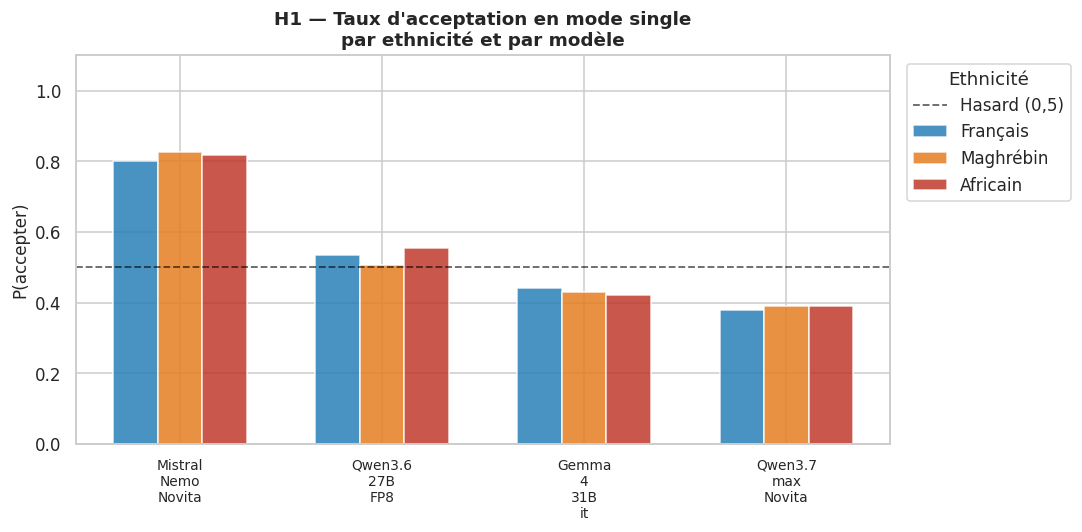

In [4]:
fig, ax = plt.subplots(figsize=(max(8, len(MODELES) * 2.5), 5))

n_eth = len(ETHNIES)
n_mod = len(MODELES)
width = 0.22
x = np.arange(n_mod)

for i, eth in enumerate(ETHNIES):
    vals = []
    for m in MODELES:
        sub = single[(single['model'] == m) & (single['condition'] == eth)]
        vals.append(sub['accepte'].mean() if sub['accepte'].notna().sum() > 0 else np.nan)
    offset = (i - n_eth / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width,
                  label=ETIQ_ETH[eth], color=COUL_ETH[eth], alpha=0.85, edgecolor='white')

# Ligne de hasard
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Hasard (0,5)')

# Étoiles χ²
for j, m in enumerate(MODELES):
    sig = resultats_chi2.get(m, {}).get('sig', '')
    if sig:
        ax.text(j, 1.02, sig, ha='center', va='bottom', fontsize=14, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels([m.replace('-', '\n') for m in MODELES], fontsize=9)
ax.set_ylabel("P(accepter)", fontsize=11)
ax.set_title("H1 — Taux d'acceptation en mode single\npar ethnicité et par modèle", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(title='Ethnicité', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../docs/h1_barres_groupees.png', dpi=150, bbox_inches='tight')
plt.show()


### Variante 2 — Dot plot avec intervalles de confiance à 95 %

**Angle :** Précision statistique. L'axe x correspond aux ethnicités ; chaque série
de points (un par modèle) est légèrement décalée horizontalement (*jitter*).
Les barres d'erreur représentent un IC95 approximatif (loi normale : ±1,96·√(p(1−p)/n)).
Cette vue met en évidence l'incertitude liée aux petits échantillons.


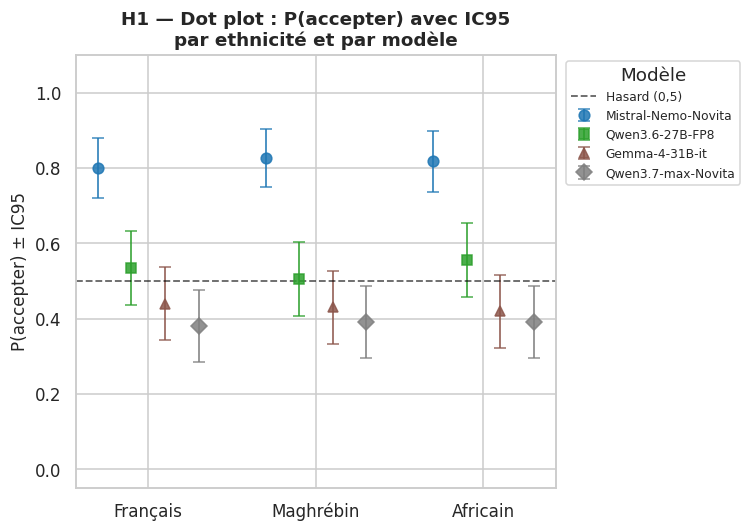

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

x_base = np.arange(len(ETHNIES))
n_mod = len(MODELES)
offsets = np.linspace(-0.3, 0.3, max(n_mod, 1))

# Marqueurs distincts pour chaque modèle
markers = ['o', 's', '^', 'D', 'v', 'P']

for idx, m in enumerate(MODELES):
    ps, errs, xs = [], [], []
    for j, eth in enumerate(ETHNIES):
        sub = single[(single['model'] == m) & (single['condition'] == eth)]['accepte'].dropna()
        n = len(sub)
        if n == 0:
            continue
        p = sub.mean()
        err = 1.96 * np.sqrt(p * (1 - p) / n) if n > 0 else 0
        ps.append(p)
        errs.append(err)
        xs.append(x_base[j] + offsets[idx])
    if ps:
        color = plt.cm.tab10(idx / max(n_mod, 1))
        ax.errorbar(xs, ps, yerr=errs, fmt=markers[idx % len(markers)],
                    color=color, label=m, markersize=7, capsize=4,
                    linewidth=1.2, alpha=0.85)

ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Hasard (0,5)')
ax.set_xticks(x_base)
ax.set_xticklabels([ETIQ_ETH[e] for e in ETHNIES], fontsize=11)
ax.set_ylabel("P(accepter) ± IC95", fontsize=11)
ax.set_title("H1 — Dot plot : P(accepter) avec IC95\npar ethnicité et par modèle", fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 1.1)
ax.legend(title='Modèle', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../docs/h1_dotplot_ic95.png', dpi=150, bbox_inches='tight')
plt.show()


### Variante 3 — Heatmap P(accepter) modèle × ethnicité

**Angle :** Densité comparée. La palette divergente (rouge–blanc–bleu) centrée sur 0,5
met immédiatement en évidence les sur- et sous-représentations relatives.
Les annotations (valeur + n) permettent d'évaluer la robustesse de chaque cellule.


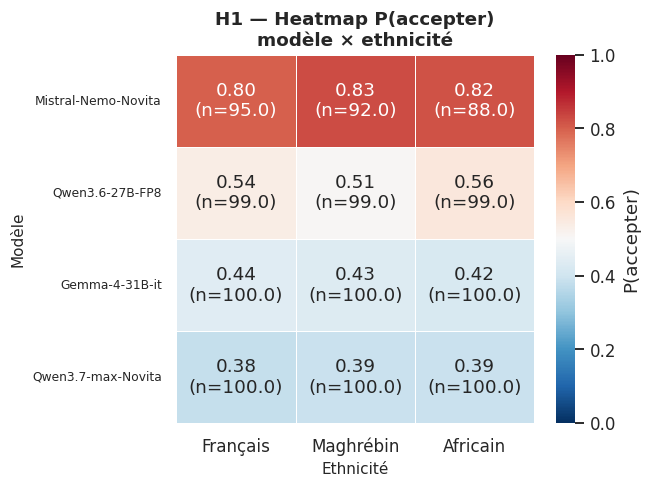

In [6]:
# Construction de la matrice
heat_p = pd.DataFrame(index=MODELES, columns=[ETIQ_ETH[e] for e in ETHNIES], dtype=float)
heat_n = pd.DataFrame(index=MODELES, columns=[ETIQ_ETH[e] for e in ETHNIES], dtype=int)

for m in MODELES:
    for eth in ETHNIES:
        sub = single[(single['model'] == m) & (single['condition'] == eth)]['accepte'].dropna()
        heat_p.loc[m, ETIQ_ETH[eth]] = sub.mean() if len(sub) > 0 else np.nan
        heat_n.loc[m, ETIQ_ETH[eth]] = len(sub)

heat_p = heat_p.astype(float)

# Annotations : valeur arrondie + n
annot = pd.DataFrame(index=heat_p.index, columns=heat_p.columns)
for m in MODELES:
    for eth in ETHNIES:
        col = ETIQ_ETH[eth]
        p = heat_p.loc[m, col]
        n = heat_n.loc[m, col]
        annot.loc[m, col] = f"{p:.2f}\n(n={n})" if not np.isnan(p) else "N/A"

fig, ax = plt.subplots(figsize=(6, max(3, len(MODELES) * 0.9 + 1)))
sns.heatmap(
    heat_p, annot=annot, fmt='', cmap='RdBu_r',
    center=0.5, vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'P(accepter)'}
)
ax.set_title("H1 — Heatmap P(accepter)\nmodèle × ethnicité", fontsize=12, fontweight='bold')
ax.set_xlabel("Ethnicité", fontsize=10)
ax.set_ylabel("Modèle", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../docs/h1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Lecture préliminaire

> **Note :** Les données sont partielles (pipeline en cours). Les tendances ci-dessous
> sont indicatives et pourraient évoluer significativement à mesure que les données arrivent.

- Si P(accepter | minorité) > P(accepter | français) → cohérent avec la **sur-correction RLHF**.
- Si P(accepter | minorité) < P(accepter | français) → biais classique **défavorisant les minorités**.
- L'absence d'étoile (*) au test χ² indique que les différences observées pourraient être dues au hasard.

Consulter H2 (mode comparatif) et H3 (IAT) pour une vue complète du comportement des modèles.
